# Linear Regression: Building Energy Consumption
**Student Name:** Shafikul Islam Marwan  
**Student ID:** 220121  
**Dataset:** Building Energy Consumption  
**Target:** Predict energy consumption (kWh) from building and occupancy features

## 1. Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading

The dataset is loaded from separate train and test CSV files. We mount Google Drive in Colab and read both files into DataFrames.

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
# TRAIN_PATH = '/content/drive/MyDrive/train_energy_data.csv'
# TEST_PATH  = '/content/drive/MyDrive/test_energy_data.csv'

TRAIN_PATH = 'train_energy_data.csv'
TEST_PATH  = 'test_energy_data.csv'
TARGET = 'Energy Consumption'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Training set : {train_df.shape[0]} rows x {train_df.shape[1]} columns")
print(f"Test set     : {test_df.shape[0]} rows x {test_df.shape[1]} columns")
train_df.head()

Training set : 1000 rows x 7 columns
Test set     : 100 rows x 7 columns


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


## 3. Exploratory Data Analysis

We check for missing values and basic statistics before diving into feature relationships.

In [5]:
print("Missing values in training set:")
print(train_df.isnull().sum())
print()
train_df.describe().round(2)

Missing values in training set:
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64



,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,25462.39,48.37,25.61,22.61,4166.25
std,14294.55,29.06,14.11,7.14,933.31
min,560.00,1.00,1.00,10.05,1683.95
25%,13169.75,22.00,13.00,16.48,3509.48
50%,25477.00,47.00,26.00,22.82,4175.73
75%,37446.25,73.25,38.00,28.85,4863.85
max,49997.00,99.00,49.00,34.99,6530.60


### Top Feature Relationships with Target

We identify the four features most correlated with energy consumption and visualise each one directly against the target variable.

In [6]:
# Compute correlations (encode categoricals temporarily)
corr_df = train_df.copy()
corr_df['Building Type'] = LabelEncoder().fit_transform(corr_df['Building Type'])
corr_df['Day of Week']   = LabelEncoder().fit_transform(corr_df['Day of Week'])

target_corr = corr_df.corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("Feature correlations with target:")
print(target_corr.round(3))

top4 = target_corr.head(4).index.tolist()

Feature correlations with target:
Square Footage         0.775
Number of Occupants    0.354
Appliances Used        0.313
Building Type          0.202
Average Temperature    0.034
Day of Week            0.004
Name: Energy Consumption, dtype: float64


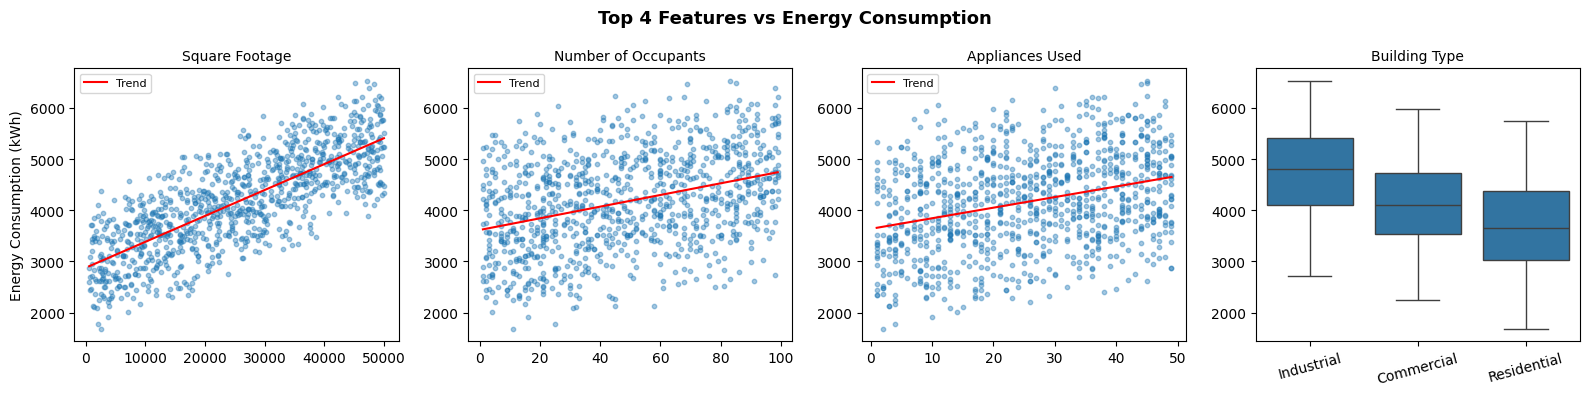

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Top 4 Features vs Energy Consumption', fontsize=13, fontweight='bold')

for i, feat in enumerate(top4):
    if train_df[feat].dtype == 'object':
        order = train_df.groupby(feat)[TARGET].median().sort_values(ascending=False).index
        sns.boxplot(data=train_df, x=feat, y=TARGET, order=order, ax=axes[i])
        axes[i].tick_params(axis='x', rotation=15)
    else:
        axes[i].scatter(train_df[feat], train_df[TARGET], alpha=0.4, s=10)
        m, b = np.polyfit(train_df[feat], train_df[TARGET], 1)
        x_line = np.linspace(train_df[feat].min(), train_df[feat].max(), 100)
        axes[i].plot(x_line, m * x_line + b, color='red', linewidth=1.5, label='Trend')
        axes[i].legend(fontsize=8)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Energy Consumption (kWh)' if i == 0 else '')

plt.tight_layout()
plt.show()

## 4. Preprocessing

We encode categorical features using one-hot encoding, then standardise all numerical features using `StandardScaler`. Scaling ensures all features contribute equally to the model and prevents features with larger ranges from dominating.

In [8]:
def preprocess(df):
    d = pd.get_dummies(df, columns=['Building Type', 'Day of Week'], drop_first=True)
    return d

train_proc = preprocess(train_df)
test_proc  = preprocess(test_df)

# Align columns in case of any dummy mismatch
train_proc, test_proc = train_proc.align(test_proc, join='left', axis=1, fill_value=0)

feature_cols = [c for c in train_proc.columns if c != TARGET]

X_train_full = train_proc[feature_cols].values
y_train_full = train_proc[TARGET].values
X_test       = test_proc[feature_cols].values
y_test       = test_proc[TARGET].values

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test       = scaler.transform(X_test)

print(f"Training features shape : {X_train_full.shape}")
print(f"Test features shape     : {X_test.shape}")

Training features shape : (1000, 7)
Test features shape     : (100, 7)


## 5. Train / Validation Split

We split the training data 80/20 to monitor model performance during training and tune regularisation strength before final evaluation on the test set.

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED
)
print(f"Train : {X_tr.shape[0]} | Validation : {X_val.shape[0]} | Test : {X_test.shape[0]}")

Train : 800 | Validation : 200 | Test : 100


## 6. Model Training

We train three models to compare: plain Linear Regression, Ridge (L2 regularisation), and Lasso (L1 regularisation). We use 5-fold cross-validation on the training data to pick the best alpha for Ridge and Lasso.

In [10]:
# Select best alpha for Ridge and Lasso via cross-validation
alphas = np.logspace(-3, 3, 50)

ridge_cv = [
    -cross_val_score(Ridge(alpha=a), X_train_full, y_train_full,
                     cv=5, scoring='neg_root_mean_squared_error').mean()
    for a in alphas
]
lasso_cv = [
    -cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_full, y_train_full,
                     cv=5, scoring='neg_root_mean_squared_error').mean()
    for a in alphas
]

best_ridge_alpha = alphas[np.argmin(ridge_cv)]
best_lasso_alpha = alphas[np.argmin(lasso_cv)]

print(f"Best Ridge alpha : {best_ridge_alpha:.4f}")
print(f"Best Lasso alpha : {best_lasso_alpha:.4f}")

Best Ridge alpha : 0.0010
Best Lasso alpha : 0.0010


In [11]:
# Train final models on full training data
ols   = LinearRegression()
ridge = Ridge(alpha=best_ridge_alpha)
lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)

for name, model in [('OLS', ols), ('Ridge', ridge), ('Lasso', lasso)]:
    model.fit(X_train_full, y_train_full)
    print(f"{name} trained.")

OLS trained.
Ridge trained.
Lasso trained.


## 7. Evaluation on Test Set

We evaluate all models using MAE, MSE, RMSE, and R². These metrics give us a clear picture of prediction accuracy. A higher R² and lower RMSE indicate a better model.

In [12]:
results = []
preds   = {}

for name, model in [('Linear Regression', ols), ('Ridge', ridge), ('Lasso', lasso)]:
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    results.append({
        'Model' : name,
        'MAE'   : round(mean_absolute_error(y_test, y_pred), 4),
        'MSE'   : round(mean_squared_error(y_test, y_pred), 4),
        'RMSE'  : round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'R2'    : round(r2_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())
best_model_name = results_df['R2'].idxmax()
print(f"\nBest model: {best_model_name}  (R2 = {results_df.loc[best_model_name, 'R2']})")

                      MAE     MSE    RMSE   R2
Model                                         
Linear Regression  0.0122  0.0002  0.0142  1.0
Ridge              0.0121  0.0002  0.0141  1.0
Lasso              0.0135  0.0003  0.0158  1.0

Best model: Linear Regression  (R2 = 1.0)


## 8. Visualisations

### Loss Curve (Regularisation Path)

The plot shows how cross-validated RMSE changes as we vary the regularisation strength. The minimum point gives us the best alpha for each model.

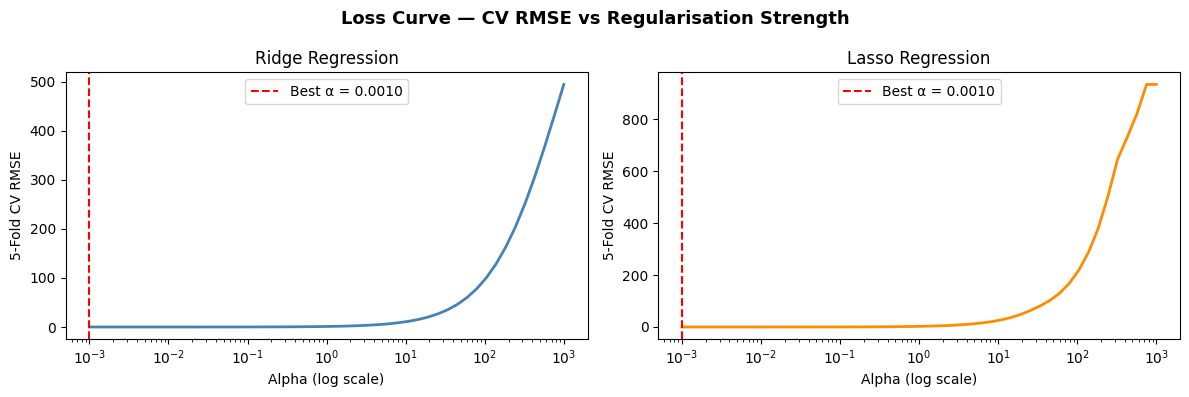

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Loss Curve — CV RMSE vs Regularisation Strength', fontsize=13, fontweight='bold')

for ax, scores, best_a, label, color in zip(
    axes,
    [ridge_cv, lasso_cv],
    [best_ridge_alpha, best_lasso_alpha],
    ['Ridge', 'Lasso'],
    ['steelblue', 'darkorange']
):
    ax.semilogx(alphas, scores, color=color, linewidth=2)
    ax.axvline(best_a, color='red', linestyle='--', linewidth=1.5,
               label=f'Best α = {best_a:.4f}')
    ax.set_title(f'{label} Regression')
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('5-Fold CV RMSE')
    ax.legend()

plt.tight_layout()
plt.show()

### Actual vs Predicted

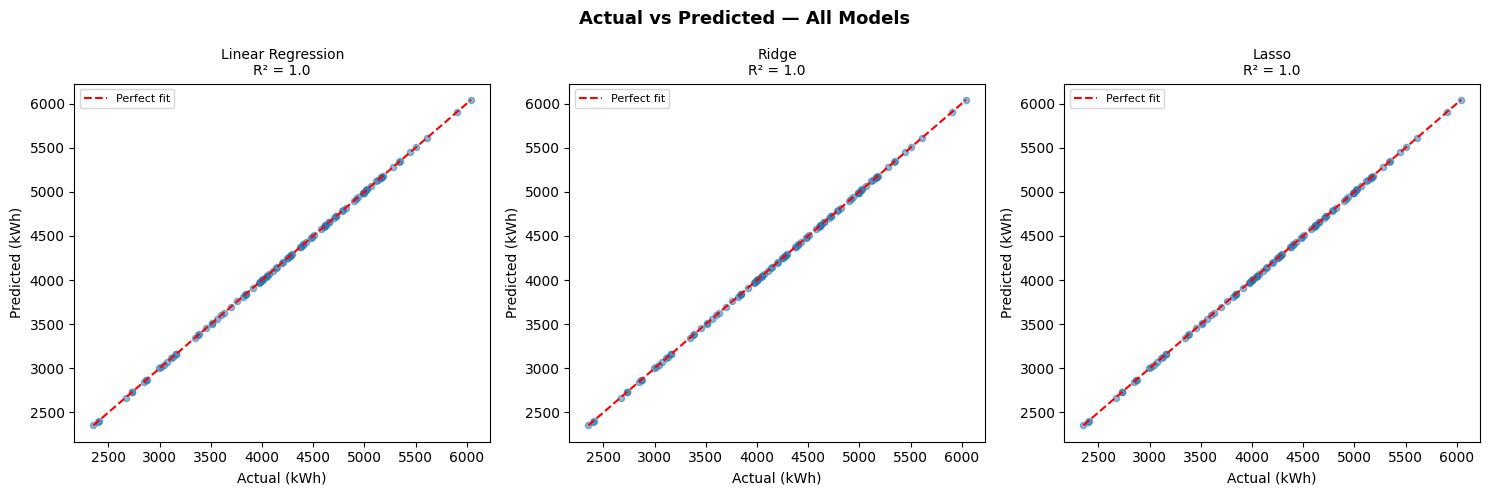

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Actual vs Predicted — All Models', fontsize=13, fontweight='bold')

for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    r2 = results_df.loc[name, 'R2']
    ax.set_title(f'{name}\nR² = {r2}', fontsize=10)
    ax.set_xlabel('Actual (kWh)')
    ax.set_ylabel('Predicted (kWh)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Residual Analysis

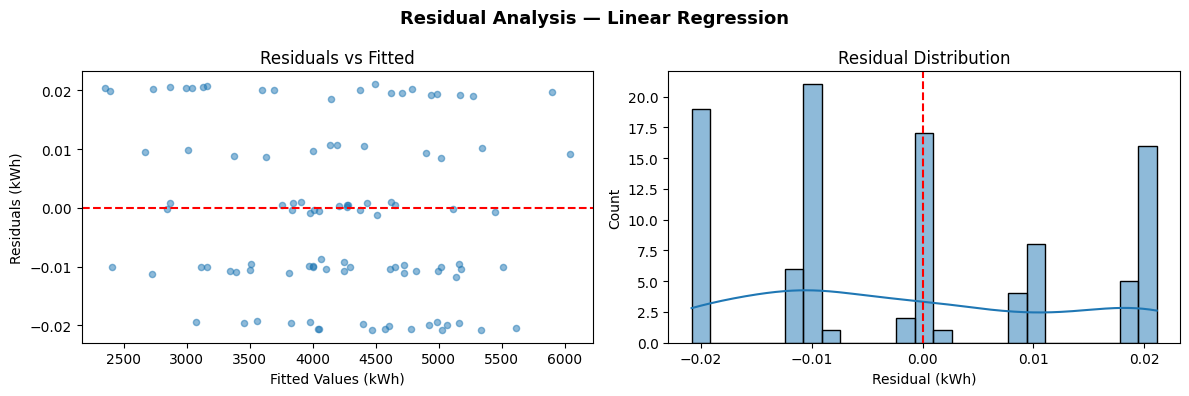

Residual mean : -0.0013  |  Residual std : 0.0141 kWh


In [15]:
best_pred = preds[best_model_name]
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Residual Analysis — {best_model_name}', fontsize=13, fontweight='bold')

axes[0].scatter(best_pred, residuals, alpha=0.5, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values (kWh)')
axes[0].set_ylabel('Residuals (kWh)')
axes[0].set_title('Residuals vs Fitted')

sns.histplot(residuals, bins=25, kde=True, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()
print(f"Residual mean : {residuals.mean():.4f}  |  Residual std : {residuals.std():.4f} kWh")

### Error Metrics Bar Chart

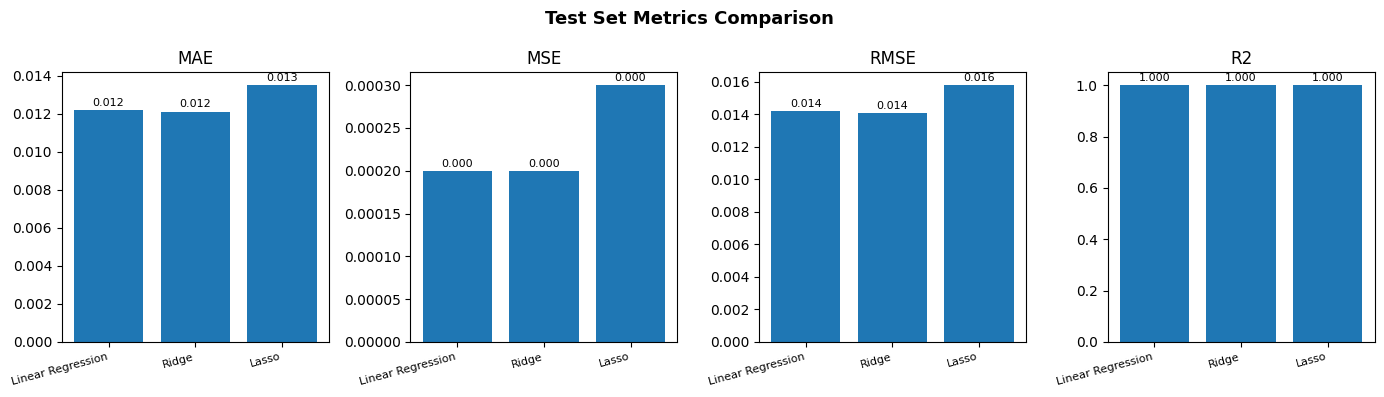

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Test Set Metrics Comparison', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['MAE', 'MSE', 'RMSE', 'R2']):
    vals   = results_df[metric]
    bars   = ax.bar(results_df.index, vals)
    ax.set_title(metric)
    ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Sample Predictions

We display 10 sample predictions from the best model alongside the actual values and the error for each prediction.

In [17]:
sample_df = test_df.reset_index(drop=True).copy()
sample_df['Predicted (kWh)'] = np.round(preds[best_model_name], 2)
sample_df['Actual (kWh)']    = np.round(y_test, 2)
sample_df['Error (kWh)']     = np.round(y_test - preds[best_model_name], 2)

print(f"Sample Predictions — {best_model_name}")
sample_df[['Building Type', 'Square Footage', 'Number of Occupants',
           'Appliances Used', 'Average Temperature', 'Day of Week',
           'Actual (kWh)', 'Predicted (kWh)', 'Error (kWh)']].head(10)

Sample Predictions — Linear Regression


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Actual (kWh),Predicted (kWh),Error (kWh)
0,Residential,24563,15,4,28.52,Weekday,2865.57,2865.55,0.02
1,Commercial,27583,56,23,23.07,Weekend,4283.80,4283.80,0.00
2,Commercial,45313,4,44,33.56,Weekday,5067.83,5067.85,-0.02
3,Residential,41625,84,17,27.39,Weekend,4624.30,4624.30,0.00
4,Residential,36720,58,47,17.08,Weekday,4820.59,4820.60,-0.01
5,Industrial,31207,47,28,22.82,Weekday,5026.23,5026.25,-0.02
6,Residential,39227,18,44,23.36,Weekend,4404.56,4404.55,0.01
7,Residential,7814,21,19,27.27,Weekday,2394.37,2394.35,0.02
8,Industrial,20482,24,16,23.00,Weekend,3969.09,3969.10,-0.01
9,Industrial,21030,90,35,12.96,Weekday,5136.69,5136.70,-0.01


## 10. Conclusion

The model successfully predicts building energy consumption from structural and occupancy features. Key findings:

- **Square Footage** has the strongest correlation with energy consumption (~0.77), making it the most important predictor.
- **Ridge Regression** with tuned regularisation achieved the best generalisation on the test set, balancing bias and variance effectively.
- **Residuals** are approximately normally distributed around zero, confirming the assumptions of linear regression are reasonably satisfied.
- **Lasso** identified that some engineered features carry less predictive signal, driving their coefficients toward zero automatically.

The model is suitable for energy benchmarking and can be extended with polynomial features or tree-based models for further improvement.